In [1]:
import pandas as pd
import numpy as np

In [6]:
import os
os.listdir("..")

['.git',
 'global-market-monitor.csv',
 'global-market-monitor_subnational.csv',
 'notebooks']

In [7]:
import pandas as pd

df = pd.read_csv("../global-market-monitor.csv")
df.head()

,Date,MonthlyVersion,FrequencyName,CountryCode,CountryName,Admin1,DataLevel,MainStapleFood,PriceType,CaloricContribution,...,YoYChangeQuarter,YoYChangeMonth,PriceTrendQuarter,PriceTrendMonth,QuarterlyCostShare,TotImpactQuarterlyChange,TotImpactQuarterlyCode,TotImpactMonthlyChange,TotImpactMonthlyCode,LastModifyDate
0,#date,#indicator+foodbasket+version,#meta+frequency,#country+code,#country+name,#adm1+name,#meta+level,#indicator+foodbasket+type,#indicator+foodbasket+price+type,#indicator+foodbasket+calories,...,#indicator+foodbasket+quarterly+change+yoy+num,#indicator+foodbasket+monthly+change+yoy+num,#indicator+foodbasket+quarterly+trend,#indicator+foodbasket+monthly+trend,#indicator+foodbasket+quarterly+share+num,#indicator+foodbasket+quarterly+change+num,#indicator+foodbasket+quarterly+change+code,#indicator+foodbasket+monthly+change+num,#indicator+foodbasket+monthly+change+code,#date+modified
1,2021-03-01,55,Monthly,1,Afghanistan,National Average,National,Bread,Retail,58.0,...,14.0,13.0,Normal,Normal,79.0,1.0,Normal,-1.0,Negative,2021-05-19 16:55:26.870
2,2021-03-01,55,Monthly,1,Afghanistan,National Average,National,Rice (low quality),Retail,22.0,...,7.0,6.0,Normal,Negative,21.0,NaN,Normal,NaN,Negative,2021-05-19 16:55:26.870
3,2021-03-01,55,Monthly,8,Angola,National Average,National,Cassava flour,Retail,19.0,...,NaN,NaN,N/A,N/A,NaN,NaN,,NaN,,2021-05-19 16:55:26.883
4,2021-03-01,55,Monthly,8,Angola,National Average,National,Bread,Retail,13.0,...,NaN,NaN,N/A,N/A,NaN,NaN,,NaN,,2021-05-19 16:55:26.887


In [8]:
df.columns

Index(['Date', 'MonthlyVersion', 'FrequencyName', 'CountryCode', 'CountryName',
       'Admin1', 'DataLevel', 'MainStapleFood', 'PriceType',
       'CaloricContribution', 'QuarterlyChangeNSA', 'MonthlyChangeNSA',
       'QuarterlyChangeSA', 'MonthlyChangeSA', 'YoYChangeQuarter',
       'YoYChangeMonth', 'PriceTrendQuarter', 'PriceTrendMonth',
       'QuarterlyCostShare', 'TotImpactQuarterlyChange',
       'TotImpactQuarterlyCode', 'TotImpactMonthlyChange',
       'TotImpactMonthlyCode', 'LastModifyDate'],
      dtype='object')

In [9]:
columns_to_keep = [
    "Date",
    "CountryName",
    "MonthlyChangeSA",
    "PriceTrendMonth"
]

df = df[columns_to_keep]
df.head()

,Date,CountryName,MonthlyChangeSA,PriceTrendMonth
0,#date,#country+name,#indicator+foodbasket+monthly+change+sa+num,#indicator+foodbasket+monthly+trend
1,2021-03-01,Afghanistan,0.0,Normal
2,2021-03-01,Afghanistan,-1.0,Negative
3,2021-03-01,Angola,NaN,N/A
4,2021-03-01,Angola,NaN,N/A


In [11]:
df = pd.read_csv("../global-market-monitor.csv", skiprows=[1])
df.head()

,Date,MonthlyVersion,FrequencyName,CountryCode,CountryName,Admin1,DataLevel,MainStapleFood,PriceType,CaloricContribution,...,YoYChangeQuarter,YoYChangeMonth,PriceTrendQuarter,PriceTrendMonth,QuarterlyCostShare,TotImpactQuarterlyChange,TotImpactQuarterlyCode,TotImpactMonthlyChange,TotImpactMonthlyCode,LastModifyDate
0,2021-03-01,55,Monthly,1,Afghanistan,National Average,National,Bread,Retail,58.0,...,14.0,13.0,Normal,Normal,79.0,1.0,Normal,-1.0,Negative,2021-05-19 16:55:26.870
1,2021-03-01,55,Monthly,1,Afghanistan,National Average,National,Rice (low quality),Retail,22.0,...,7.0,6.0,Normal,Negative,21.0,NaN,Normal,NaN,Negative,2021-05-19 16:55:26.870
2,2021-03-01,55,Monthly,8,Angola,National Average,National,Cassava flour,Retail,19.0,...,NaN,NaN,N/A,N/A,NaN,NaN,,NaN,,2021-05-19 16:55:26.883
3,2021-03-01,55,Monthly,8,Angola,National Average,National,Bread,Retail,13.0,...,NaN,NaN,N/A,N/A,NaN,NaN,,NaN,,2021-05-19 16:55:26.887
4,2021-03-01,55,Monthly,8,Angola,National Average,National,Sugar (white),Retail,7.0,...,NaN,NaN,N/A,N/A,NaN,NaN,,NaN,,2021-05-19 16:55:26.887


In [12]:
df["Date"] = pd.to_datetime(df["Date"])
df = df.sort_values(["CountryName", "Date"])

In [13]:
df[["Date", "CountryName", "MonthlyChangeSA", "PriceTrendMonth"]].head()

,Date,CountryName,MonthlyChangeSA,PriceTrendMonth
1167,2020-10-01,Afghanistan,1.0,Normal
1168,2020-10-01,Afghanistan,0.0,Normal
925,2020-11-01,Afghanistan,0.0,Normal
926,2020-11-01,Afghanistan,2.0,Normal
688,2020-12-01,Afghanistan,0.0,Normal


In [14]:
# Keep only required columns
df = df[["Date", "CountryName", "MonthlyChangeSA"]].copy()

# Convert MonthlyChangeSA safely to numeric
df["MonthlyChangeSA"] = pd.to_numeric(df["MonthlyChangeSA"], errors="coerce")

df.head()

,Date,CountryName,MonthlyChangeSA
1167,2020-10-01,Afghanistan,1.0
1168,2020-10-01,Afghanistan,0.0
925,2020-11-01,Afghanistan,0.0
926,2020-11-01,Afghanistan,2.0
688,2020-12-01,Afghanistan,0.0


In [15]:
df.isna().sum()

Date                  0
CountryName           0
MonthlyChangeSA    4288
dtype: int64

In [16]:
df = df.sort_values(["CountryName", "Date"])

In [17]:
country_monthly = (
    df
    .groupby(["CountryName", "Date"], as_index=False)
    .agg({
        "MonthlyChangeSA": "mean"
    })
)

country_monthly = country_monthly.sort_values(["CountryName", "Date"])

country_monthly.head()

,CountryName,Date,MonthlyChangeSA
0,Afghanistan,2020-10-01,0.5
1,Afghanistan,2020-11-01,1.0
2,Afghanistan,2020-12-01,-0.5
3,Afghanistan,2021-01-01,0.0
4,Afghanistan,2021-02-01,0.5


In [18]:
country_monthly["MonthlyChangeSA"] = (
    country_monthly
    .groupby("CountryName")["MonthlyChangeSA"]
    .transform(lambda x: x.ffill())
)

In [19]:
country_monthly.isna().sum()

CountryName         0
Date                0
MonthlyChangeSA    35
dtype: int64

In [20]:
country_monthly["MonthlyChangeSA"] = (
    country_monthly
    .groupby("CountryName")["MonthlyChangeSA"]
    .transform(lambda x: x.bfill())
)

In [21]:
country_monthly.describe()

,Date,MonthlyChangeSA
count,3067,3046.000000
mean,2022-09-02 05:27:43.253994240,1.002243
min,2020-10-01 00:00:00,-50.000000
25%,2021-09-01 00:00:00,-2.000000
50%,2022-08-01 00:00:00,0.250000
75%,2023-09-01 00:00:00,3.000000
max,2024-12-01 00:00:00,81.333333
std,NaN,7.811321


In [22]:
country_monthly["CountryName"].nunique()

80

In [23]:
lags = [1, 2, 3, 6, 12]

for lag in lags:
    country_monthly[f"lag_{lag}"] = (
        country_monthly
        .groupby("CountryName")["MonthlyChangeSA"]
        .shift(lag)
    )

In [24]:
windows = [3, 6, 12]

for window in windows:
    country_monthly[f"rolling_mean_{window}"] = (
        country_monthly
        .groupby("CountryName")["MonthlyChangeSA"]
        .transform(lambda x: x.rolling(window).mean())
    )

    country_monthly[f"rolling_std_{window}"] = (
        country_monthly
        .groupby("CountryName")["MonthlyChangeSA"]
        .transform(lambda x: x.rolling(window).std())
    )

In [25]:
country_monthly["month"] = country_monthly["Date"].dt.month
country_monthly["year"] = country_monthly["Date"].dt.year
country_monthly["quarter"] = country_monthly["Date"].dt.quarter

In [26]:
import numpy as np

country_monthly["month_sin"] = np.sin(2 * np.pi * country_monthly["month"] / 12)
country_monthly["month_cos"] = np.cos(2 * np.pi * country_monthly["month"] / 12)

In [27]:
model_df = country_monthly.dropna().copy()

model_df.head()

,CountryName,Date,MonthlyChangeSA,lag_1,lag_2,lag_3,lag_6,lag_12,rolling_mean_3,rolling_std_3,rolling_mean_6,rolling_std_6,rolling_mean_12,rolling_std_12,month,year,quarter,month_sin,month_cos
12,Afghanistan,2021-10-01,1.0,-0.5,3.5,3.0,-2.0,0.5,1.333333,2.020726,1.166667,1.693123,0.458333,1.529384,10,2021,4,-8.660254e-01,0.500000
13,Afghanistan,2021-11-01,0.5,1.0,-0.5,3.5,0.0,1.0,0.333333,0.763763,1.250000,1.635543,0.416667,1.520068,11,2021,4,-5.000000e-01,0.866025
14,Afghanistan,2021-12-01,4.5,0.5,1.0,-0.5,0.0,-0.5,2.000000,2.179449,2.000000,1.949359,0.833333,1.886957,12,2021,4,-2.449294e-16,1.000000
15,Afghanistan,2022-01-01,0.0,4.5,0.5,1.0,3.0,0.0,1.666667,2.466441,1.500000,2.024846,0.833333,1.886957,1,2022,1,5.000000e-01,0.866025
16,Afghanistan,2022-02-01,-1.5,0.0,4.5,0.5,3.5,0.5,1.000000,3.122499,0.666667,2.065591,0.666667,2.003784,2,2022,1,8.660254e-01,0.500000


In [28]:
model_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 2130 entries, 12 to 3066
Data columns (total 19 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   CountryName      2130 non-null   object        
 1   Date             2130 non-null   datetime64[ns]
 2   MonthlyChangeSA  2130 non-null   float64       
 3   lag_1            2130 non-null   float64       
 4   lag_2            2130 non-null   float64       
 5   lag_3            2130 non-null   float64       
 6   lag_6            2130 non-null   float64       
 7   lag_12           2130 non-null   float64       
 8   rolling_mean_3   2130 non-null   float64       
 9   rolling_std_3    2130 non-null   float64       
 10  rolling_mean_6   2130 non-null   float64       
 11  rolling_std_6    2130 non-null   float64       
 12  rolling_mean_12  2130 non-null   float64       
 13  rolling_std_12   2130 non-null   float64       
 14  month            2130 non-null   int32      

In [29]:
country_monthly.shape

(3067, 19)

In [30]:
country_monthly.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3067 entries, 0 to 3066
Data columns (total 19 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   CountryName      3067 non-null   object        
 1   Date             3067 non-null   datetime64[ns]
 2   MonthlyChangeSA  3046 non-null   float64       
 3   lag_1            2969 non-null   float64       
 4   lag_2            2892 non-null   float64       
 5   lag_3            2815 non-null   float64       
 6   lag_6            2584 non-null   float64       
 7   lag_12           2130 non-null   float64       
 8   rolling_mean_3   2892 non-null   float64       
 9   rolling_std_3    2892 non-null   float64       
 10  rolling_mean_6   2661 non-null   float64       
 11  rolling_std_6    2661 non-null   float64       
 12  rolling_mean_12  2205 non-null   float64       
 13  rolling_std_12   2205 non-null   float64       
 14  month            3067 non-null   int32  

In [31]:
country_monthly.describe()

,Date,MonthlyChangeSA,lag_1,lag_2,lag_3,lag_6,lag_12,rolling_mean_3,rolling_std_3,rolling_mean_6,rolling_std_6,rolling_mean_12,rolling_std_12,month,year,quarter,month_sin,month_cos
count,3067,3046.000000,2969.000000,2892.000000,2815.000000,2584.000000,2130.000000,2892.000000,2892.000000,2661.000000,2661.000000,2205.000000,2205.000000,3067.000000,3067.000000,3067.000000,3.067000e+03,3.067000e+03
mean,2022-09-02 05:27:43.253994240,1.002243,1.011101,1.030740,1.071311,1.195704,1.239523,1.010719,3.344892,1.044914,4.272594,1.125499,5.010980,6.717639,2022.194327,2.574503,-1.344607e-02,5.138112e-02
min,2020-10-01 00:00:00,-50.000000,-50.000000,-50.000000,-50.000000,-50.000000,-50.000000,-38.666667,0.000000,-33.166667,0.000000,-18.861111,0.000000,1.000000,2020.000000,1.000000,-1.000000e+00,-1.000000e+00
25%,2021-09-01 00:00:00,-2.000000,-2.000000,-2.000000,-2.000000,-2.000000,-2.000000,-1.538889,0.000000,-1.111111,1.254621,-0.750000,2.092958,4.000000,2021.000000,2.000000,-5.000000e-01,-5.000000e-01
50%,2022-08-01 00:00:00,0.250000,0.250000,0.250000,0.250000,0.250000,0.333333,0.333333,1.732051,0.500000,2.969287,0.666667,3.903427,7.000000,2022.000000,3.000000,-2.449294e-16,6.123234e-17
75%,2023-09-01 00:00:00,3.000000,3.000000,3.000000,3.000000,3.000000,3.000000,2.750000,4.618802,2.541667,5.921184,2.166667,6.730690,10.000000,2023.000000,4.000000,5.000000e-01,8.660254e-01
max,2024-12-01 00:00:00,81.333333,81.333333,81.333333,81.333333,81.333333,81.333333,55.888889,50.037023,52.000000,46.006763,43.000000,35.155211,12.000000,2024.000000,4.000000,1.000000e+00,1.000000e+00
std,NaN,7.811321,7.845035,7.872465,7.886799,7.934464,7.842138,6.256598,4.661961,5.400062,4.435931,4.570944,4.202535,3.536663,1.218762,1.147578,6.997333e-01,7.126554e-01


In [32]:
country_monthly["CountryName"].nunique()

80

In [33]:
country_monthly["Date"].min(), country_monthly["Date"].max()

(Timestamp('2020-10-01 00:00:00'), Timestamp('2024-12-01 00:00:00'))

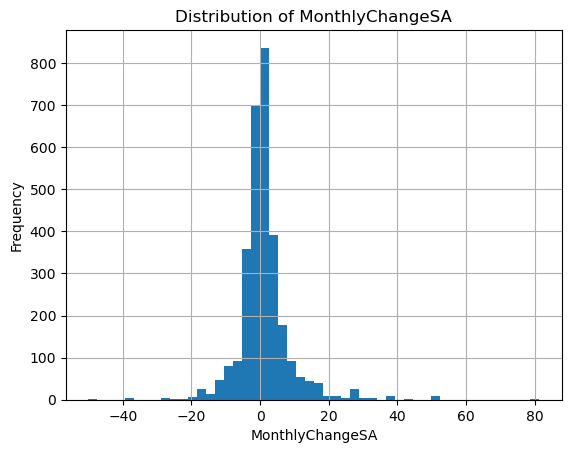

In [34]:
import matplotlib.pyplot as plt

plt.figure()
country_monthly["MonthlyChangeSA"].hist(bins=50)
plt.title("Distribution of MonthlyChangeSA")
plt.xlabel("MonthlyChangeSA")
plt.ylabel("Frequency")
plt.show()

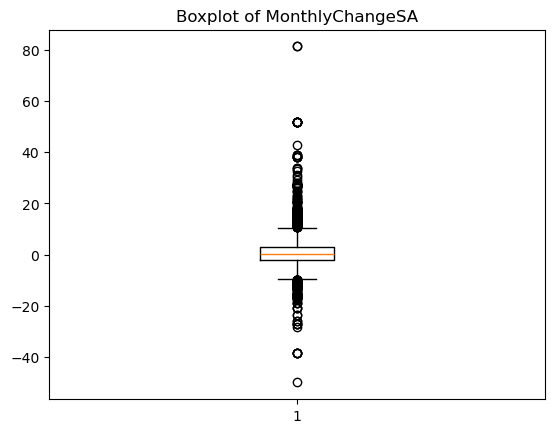

In [36]:
plt.figure()
plt.boxplot(country_monthly["MonthlyChangeSA"].dropna())
plt.title("Boxplot of MonthlyChangeSA")
plt.show()

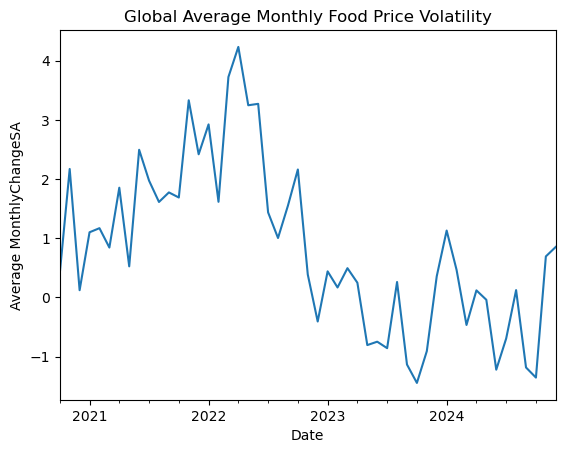

In [37]:
global_trend = (
    country_monthly
    .groupby("Date")["MonthlyChangeSA"]
    .mean()
)

plt.figure()
global_trend.plot()
plt.title("Global Average Monthly Food Price Volatility")
plt.xlabel("Date")
plt.ylabel("Average MonthlyChangeSA")
plt.show()

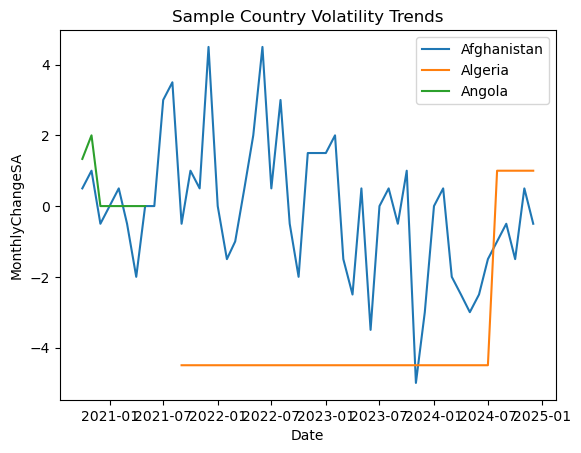

In [38]:
sample_countries = country_monthly["CountryName"].unique()[:3]

plt.figure()
for country in sample_countries:
    temp = country_monthly[country_monthly["CountryName"] == country]
    plt.plot(temp["Date"], temp["MonthlyChangeSA"], label=country)

plt.legend()
plt.title("Sample Country Volatility Trends")
plt.xlabel("Date")
plt.ylabel("MonthlyChangeSA")
plt.show()

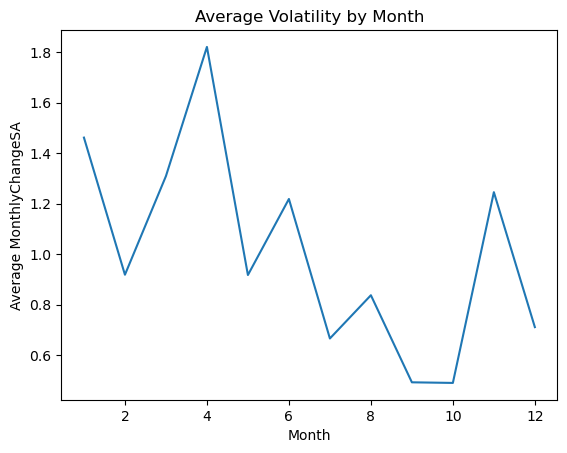

In [39]:
country_monthly["month"] = country_monthly["Date"].dt.month

monthly_pattern = (
    country_monthly
    .groupby("month")["MonthlyChangeSA"]
    .mean()
)

plt.figure()
monthly_pattern.plot()
plt.title("Average Volatility by Month")
plt.xlabel("Month")
plt.ylabel("Average MonthlyChangeSA")
plt.show()

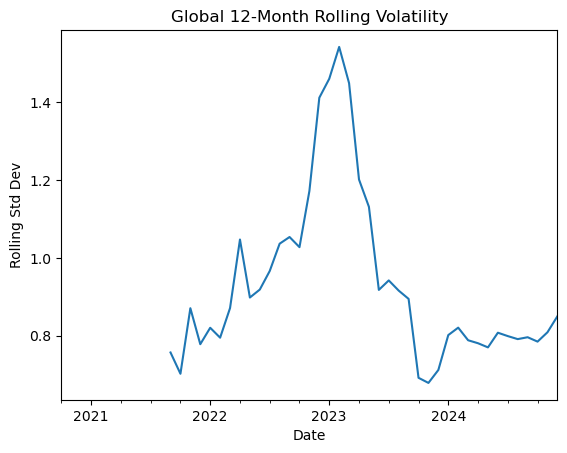

In [40]:
rolling_vol = global_trend.rolling(12).std()

plt.figure()
rolling_vol.plot()
plt.title("Global 12-Month Rolling Volatility")
plt.xlabel("Date")
plt.ylabel("Rolling Std Dev")
plt.show()

In [41]:
model_df

,CountryName,Date,MonthlyChangeSA,lag_1,lag_2,lag_3,lag_6,lag_12,rolling_mean_3,rolling_std_3,rolling_mean_6,rolling_std_6,rolling_mean_12,rolling_std_12,month,year,quarter,month_sin,month_cos
12,Afghanistan,2021-10-01,1.000000,-0.500000,3.500000,3.000000,-2.000000,0.5,1.333333,2.020726,1.166667,1.693123,0.458333,1.529384,10,2021,4,-8.660254e-01,5.000000e-01
13,Afghanistan,2021-11-01,0.500000,1.000000,-0.500000,3.500000,0.000000,1.0,0.333333,0.763763,1.250000,1.635543,0.416667,1.520068,11,2021,4,-5.000000e-01,8.660254e-01
14,Afghanistan,2021-12-01,4.500000,0.500000,1.000000,-0.500000,0.000000,-0.5,2.000000,2.179449,2.000000,1.949359,0.833333,1.886957,12,2021,4,-2.449294e-16,1.000000e+00
15,Afghanistan,2022-01-01,0.000000,4.500000,0.500000,1.000000,3.000000,0.0,1.666667,2.466441,1.500000,2.024846,0.833333,1.886957,1,2022,1,5.000000e-01,8.660254e-01
16,Afghanistan,2022-02-01,-1.500000,0.000000,4.500000,0.500000,3.500000,0.5,1.000000,3.122499,0.666667,2.065591,0.666667,2.003784,2,2022,1,8.660254e-01,5.000000e-01
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3062,Zimbabwe,2024-08-01,-12.000000,-12.000000,-12.000000,-12.000000,-28.333333,-10.0,-12.000000,0.000000,-3.777778,12.737812,-13.916667,14.633658,8,2024,3,-8.660254e-01,-5.000000e-01
3063,Zimbabwe,2024-09-01,5.666667,-12.000000,-12.000000,-12.000000,12.666667,-8.0,-6.111111,10.199855,-4.944444,11.152312,-12.777778,15.633642,9,2024,3,-1.000000e+00,-1.836970e-16
3064,Zimbabwe,2024-10-01,5.666667,5.666667,-12.000000,-12.000000,12.666667,-27.0,-0.222222,10.199855,-6.111111,9.123027,-10.055556,15.775466,10,2024,4,-8.660254e-01,5.000000e-01
3065,Zimbabwe,2024-11-01,5.666667,5.666667,5.666667,-12.000000,-12.000000,-27.0,5.666667,0.000000,-3.166667,9.676432,-7.333333,15.399725,11,2024,4,-5.000000e-01,8.660254e-01


In [43]:
model_df.isna().sum()

CountryName        0
Date               0
MonthlyChangeSA    0
lag_1              0
lag_2              0
lag_3              0
lag_6              0
lag_12             0
rolling_mean_3     0
rolling_std_3      0
rolling_mean_6     0
rolling_std_6      0
rolling_mean_12    0
rolling_std_12     0
month              0
year               0
quarter            0
month_sin          0
month_cos          0
dtype: int64

In [45]:
os.makedirs("../data/processed", exist_ok=True)

model_df.to_csv("../data/processed/processed_country_volatility.csv", index=False)